# Recover data position and resume

Runnable locally on CPU or on a Cloud TPU VM.

- Persist model/optimizer/key and Grain iterator position at one boundary.
- Replay across an epoch transition and compare every future batch.
- Diagnose reader-only and model-only restores.
- Reject changed pipeline configuration and state the tested recovery limits.

Let’s bring model recovery and data recovery together. We’ll interrupt training after two batches, save both the model state and the next-read position, then continue. Comparing the remaining batches with an uninterrupted run will show whether we really resumed at the same point, including across an epoch boundary.

## The idea

Exact recovery joins numerical state and input-pipeline state at one completed update. Mixing boundaries can repeat or skip examples while producing a plausible training curve.

## Align model time with data time

If saved weights include the C/D update but the iterator still points to C/D, recovery trains on that batch again. If the iterator is one batch too far ahead, it skips data. Both runs can continue without a shape error.

Draw one vertical boundary after an update and align parameters, optimizer, key and cursor with it. The next restored arrow must consume the same examples as the uninterrupted run.

When comparing loss trajectories, align measurement conventions too. A loss before an update and a loss after it describe different states. Compare IDs and state values alongside loss, because similar scalar losses can conceal different training histories.

$$
(k_{t+1}, k_{\text{step}}) = \operatorname{split}(k_t), \qquad i_{t+1} = (i_t + B) \bmod N
$$

### One checkpoint, one completed-step boundary

**Predict:** Why reject a resume even when its first loss nearly matches the reference?

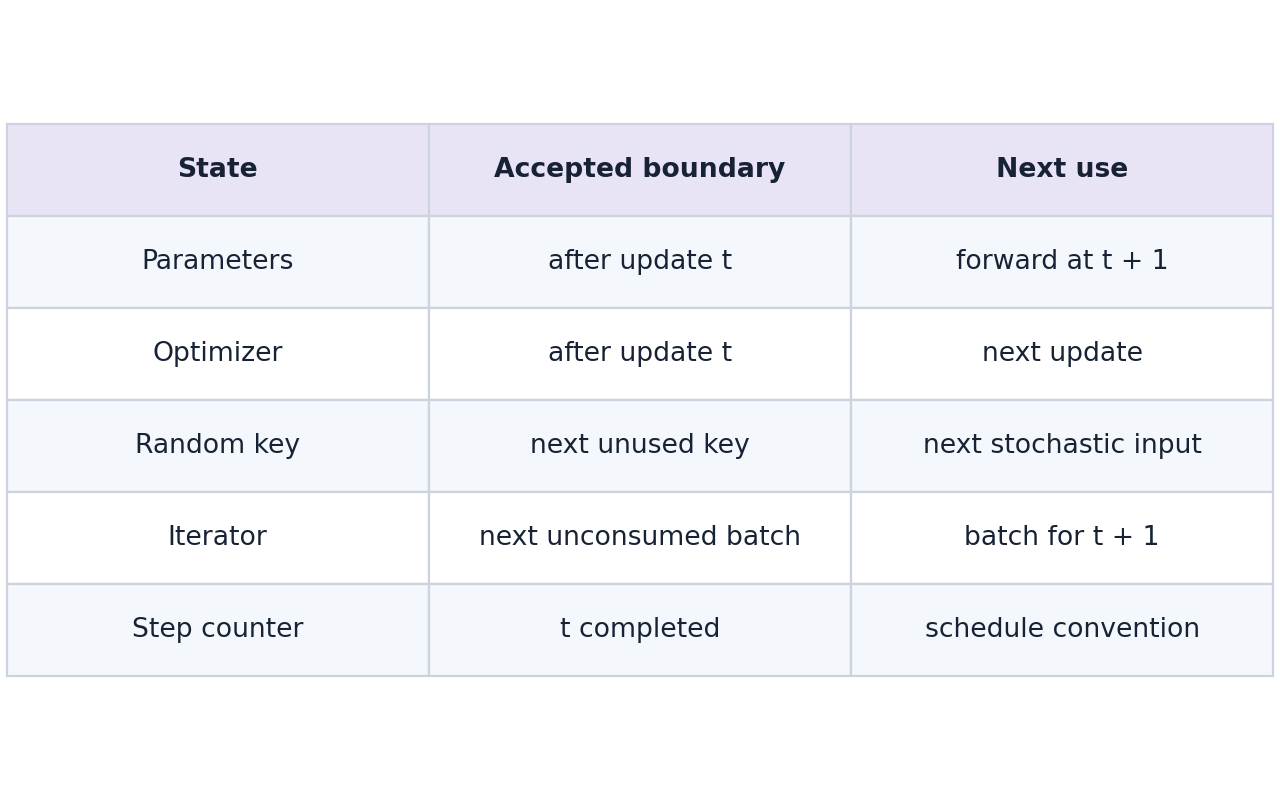

*Architecture and dataflow mechanism diagram.*

Read down the middle column: all state describes the same completed update. Across each row is its next use. An older cursor repeats data and a newer cursor skips it. The table shows logical state, not wall-clock timing.

### Pause and reason

Why reject a resume even when its first loss nearly matches the reference?

<details><summary>Compare your reasoning</summary>

Different data or optimizer state can coincidentally produce similar loss. Exact continuation requires the intended full state and data boundary.

</details>

## Commit one logical boundary

consume retrieves a batch, computes an update and returns the updated training state. After two calls, the model step is two and the iterator points at batch three. We pack that iterator snapshot in the same Orbax payload as the model, Adam memory, random stream and contract.

A real prefetcher may prepare data ahead of consumption; the snapshot semantics must refer to the iterator boundary supported by its implementation. This tutorial uses a serial Grain loader and synchronous checkpointing, so no speculative workers or asynchronous outstanding writes complicate the boundary. Do not extrapolate this protocol to an arbitrary data queue without checking its restore contract.

```text
read batch 1 → update 1
read batch 2 → update 2 → save {state_2,next_read_3}
restore → read batch 3 → update 3
```

## Persist opaque iterator bytes without editing them

Grain get_state returns bytes. We store them as a fixed-size uint8 buffer plus length so the Orbax restore target has a predictable shape. set_state receives the original byte sequence recovered from that buffer. The application does not inspect or patch Grain internal counters.

The buffer capacity is $4096$ bytes and over-capacity snapshots fail. It is a teaching representation, not a general replacement for Grain checkpoint integration handlers. Restore is supported for this tested source/sampler/worker configuration. Changing those settings may invalidate a snapshot, so our contract also records seed, batch size, record count and source revision.

## Audit the future, including an epoch transition

There are twelve records in each of two epochs and three four-example batches per epoch. We checkpoint after two batches. The remaining four batches are the final batch of epoch zero followed by all three batches of epoch one. Compare each future ID vector and each future loss in order, then compare every final state leaf.

Comparing only final loss can miss skipped or repeated observations, particularly on an easy dataset. Comparing only IDs can miss an optimizer/key reset. Comparing only weights can miss a count or random-state error that changes a subsequent step. The combined check targets all three failure classes.

```text
epoch 0: batch 1 | batch 2 | checkpoint | batch 3
epoch 1: batch 4 | batch 5 | batch 6
replay compares IDs + losses + params + Adam + key + step
```

## Define the limits of this recovery claim

The payload contract contains dataset SHA256, source revision, counts, ordering configuration, update configuration, PRNG implementation and package versions. Refuse a mismatch rather than silently announcing a resumed run. This is intentionally stricter than claiming compatibility between arbitrary versions.

The local directory is temporary and the writer is synchronous. The lesson verifies readable files and CPU replay after reconstructing objects in the same process; it does not simulate power loss, a separate machine, multi-host orchestration, async interruption or remote storage behavior. Your portfolio report should state those limits and identify the next failure mode to test. Production use should adopt the library-supported combined handlers/manager and test its completion/recovery boundaries.

## Prepare the data and state

Create main.py in your course workspace. Use the tested course environment and add this block first.

In [1]:
# Step 1 — Prepare the data and state: This setup makes the dataset and software assumptions explicit.
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update("jax_platforms","cpu")
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import tempfile
import json
import hashlib
from pathlib import Path
# Configure or step the Optax optimizer state (`tx`).
tx = optax.adam(0.05)
# Function `initial_state()` implementing this stage's computation:
def initial_state():
    # Construct `params` via `{"weight":jnp.array(0.,jnp.float32),"bias":jnp.array...`
    params = {"weight":jnp.array(0.,jnp.float32),"bias":jnp.array(0.,jnp.float32)}
    # Return `{'params': params, 'optimizer': tx.init(params), 'key_data': jax.random.key_data(jax.random.key(7, impl='threefry2x32')), 'step': jnp.array(0, jnp.int32)}` to the caller.
    return {"params":params,"optimizer":tx.init(params),
            "key_data":jax.random.key_data(jax.random.key(7,impl="threefry2x32")),
            "step":jnp.array(0,jnp.int32)}
# Function `pack_bytes(raw, capacity)` implementing this stage's computation:
def pack_bytes(raw,capacity=4096):
    # Guard input contract (`len(raw) > capacity`) and fail fast if violated.
    if len(raw)>capacity:
        raise ValueError("Snapshot exceeds tutorial fixed-byte capacity")
    # Allocate initialized array `buffer` with the specified shape and dtype.
    buffer = np.zeros(capacity,dtype=np.uint8)
    # Run `np.frombuffer` to compute `buffer[:len(raw)]`.
    buffer[:len(raw)] = np.frombuffer(raw,dtype=np.uint8)
    # Return `{'buffer': buffer, 'length': np.array(len(raw), dtype=np.int32)}` to the caller.
    return {"buffer":buffer,"length":np.array(len(raw),dtype=np.int32)}
# Function `unpack_bytes(packed)` implementing this stage's computation:
def unpack_bytes(packed):
    # Evaluate `packed['length']` and convert the result into Python scalar/collection `length`.
    length = int(packed["length"])
    # Guard input contract (`not 0 <= length <= len(packed['buffer'])`) and fail fast if violated.
    if not 0 <= length <= len(packed["buffer"]):
        raise ValueError("Invalid snapshot length")
    # Return `np.asarray(packed['buffer'], dtype=np.uint8)[:length].tobytes()` to the caller.
    return np.asarray(packed["buffer"],dtype=np.uint8)[:length].tobytes()
# Function `same_tree(left, right)` implementing this stage's computation:
def same_tree(left,right):
    # Assert invariant `jax.tree.structure(left)==jax.tree.structure(right)` holds
    assert jax.tree.structure(left)==jax.tree.structure(right)
    # Iterate over `(a, b)` to step through the computation:
    for a,b in zip(jax.tree.leaves(left),jax.tree.leaves(right)):
        # Convert `(host_a, host_b)` to a host NumPy array for inspection or verification.
        host_a,host_b = np.asarray(a),np.asarray(b)
        # Check tensor shape invariant: `host_a.shape==host_b.shape and host_a.dtype==host_b.dtype`
        assert host_a.shape==host_b.shape and host_a.dtype==host_b.dtype
        # Branch on condition `np.issubdtype(host_a.dtype, np.integer)`:
        if np.issubdtype(host_a.dtype,np.integer):
            np.testing.assert_array_equal(host_a,host_b)
        else:
            np.testing.assert_allclose(host_a,host_b,rtol=1e-6,atol=1e-7)
# Define `step(state, x, y)` to evaluate the objective and its automatic derivatives:
def step(state,x,y):
    # Sample deterministic random values into `key` using an explicit PRNG key.
    key = jax.random.wrap_key_data(state["key_data"],impl="threefry2x32")
    # Create or split explicit PRNG key(s) (`(next_key, sample_key)`) for reproducible randomness.
    next_key,sample_key = jax.random.split(key)
    # Sample deterministic random values into `target_noise` using an explicit PRNG key.
    target_noise = 0.01*jax.random.normal(sample_key,y.shape)
    # Function `objective(params)` implementing this stage's computation:
    def objective(params):
        # Compute `residual` from `params["weight"]*x+params["bias"]-(y+target_noise)`
        residual = params["weight"]*x+params["bias"]-(y+target_noise)
        # Return `jnp.mean(residual ** 2)` to the caller.
        return jnp.mean(residual**2)
    # Evaluate both scalar loss and parameter gradients in one pass (`(value, gradient)`).
    value,gradient = jax.value_and_grad(objective)(state["params"])
    # Run `tx.update` to compute `(updates, opt_state)`.
    updates,opt_state = tx.update(gradient,state["optimizer"],state["params"])
    # Initialize explicit deterministic PRNG key `next_state`.
    next_state = {"params":optax.apply_updates(state["params"],updates),
                  "optimizer":opt_state,"key_data":jax.random.key_data(next_key),
                  "step":state["step"]+1}
    # Return `(next_state, value)` to the caller.
    return next_state,value
# Function `package_versions()` implementing this stage's computation:
def package_versions():
    # Import importlib.metadata for this computation.
    import importlib.metadata
    # Return `{name: importlib.metadata.version(name) for name in ('jax', 'numpy', 'optax', 'orbax-checkpoint')}` to the caller.
    return {name:importlib.metadata.version(name) for name in ("jax","numpy","optax","orbax-checkpoint")}
# Function `encode_contract(contract)` implementing this stage's computation:
def encode_contract(contract):
    # Return `pack_bytes(json.dumps(contract, sort_keys=True).encode())` to the caller.
    return pack_bytes(json.dumps(contract,sort_keys=True).encode())
# Function `validate_contract(saved, expected)` implementing this stage's computation:
def validate_contract(saved,expected):
    # Read or serialize artifact data on disk (`actual`).
    actual = json.loads(unpack_bytes(saved))
    # Guard input contract (`actual != expected`) and fail fast if violated.
    if actual != expected:
        raise ValueError("Checkpoint contract differs: verify dataset, optimizer configuration, key implementation and package versions")
# Run `tempfile.TemporaryDirectory` to compute `workspace`.
workspace = tempfile.TemporaryDirectory()
# Read or serialize artifact data on disk (`root`).
root = Path(workspace.name)

# Import required JAX, NumPy, and standard-library modules.
import numpy as np
import grain.python as grain
# Module/container class `TutorialSource` encapsulating model parameters and forward pass:
class TutorialSource:
    # Function `__init__(self, count)` implementing this stage's computation:
    def __init__(self,count=12):
        # Compute `self.count` from `count`
        self.count = count
    # Function `__len__(self)` implementing this stage's computation:
    def __len__(self):
        # Return `self.count` to the caller.
        return self.count
    # Function `__getitem__(self, index)` implementing this stage's computation:
    def __getitem__(self,index):
        # Cast or evaluate `value` in explicit floating-point precision.
        value = np.float32(index/10)
        # Return `{'id': np.int64(index), 'x': value, 'y': np.float32(2 * value - 1)}` to the caller.
        return {"id":np.int64(index),"x":value,"y":np.float32(2*value-1)}
    # Function `__repr__(self)` implementing this stage's computation:
    def __repr__(self):
        # Return `f'TutorialSource(v1,n={self.count})'` to the caller.
        return f"TutorialSource(v1,n={self.count})"
# Function `make_loader(seed, batch_size, count, drop_remainder)` implementing this stage's computation:
def make_loader(seed=42,batch_size=4,count=12,drop_remainder=False):
    # Return `grain.DataLoader(data_source=TutorialSource(count), sampler=grain.IndexSampler(num_records=count, num_epochs=2, shuffle=True, seed=seed), operations=[grain.Batch(batch_size, drop_remainder=drop_remainder)], worker_count=0)` to the caller.
    return grain.DataLoader(
        data_source=TutorialSource(count),
        sampler=grain.IndexSampler(num_records=count,num_epochs=2,shuffle=True,seed=seed),
        operations=[grain.Batch(batch_size,drop_remainder=drop_remainder)],
        worker_count=0)

This setup makes the dataset and software assumptions explicit. No external dataset or accelerator is required.

## Build the pipeline or state transition

Append this block to the same file; follow the named state objects through each function.

In [2]:
# Step 2 — Build the pipeline or state transition: The function boundaries expose which inputs determine the next...
def data_contract(seed=42):
    # Run `TutorialSource` to compute `source`.
    source = TutorialSource()
    # Compute `values` from `np.array([[source[i]["x"],source[i]["y"]] for i in r...`
    values = np.array([[source[i]["x"],source[i]["y"]] for i in range(len(source))],dtype=np.float32)
    # Return `{'schema': 1, 'seed': seed, 'batch_size': 4, 'count': 12, 'source': 'TutorialSource(v1,n=12)', 'sha256': hashlib.sha256(values.tobytes()).hexdigest(), 'learning_rate': 0.05, 'optimizer': 'adam', 'key_impl': 'threefry2x32', 'versions': dict(package_versions(), grain=__import__('importlib.metadata', fromlist=['version']).version('grain'))}` to the caller.
    return {"schema":1,"seed":seed,"batch_size":4,"count":12,"source":"TutorialSource(v1,n=12)",
            "sha256":hashlib.sha256(values.tobytes()).hexdigest(),
            "learning_rate":0.05,"optimizer":"adam","key_impl":"threefry2x32",
            "versions":dict(package_versions(),grain=__import__("importlib.metadata",fromlist=["version"]).version("grain"))}
# Function `consume(state, iterator, count)` implementing this stage's computation:
def consume(state,iterator,count):
    # Compute `losses` from `[]`
    losses=[]
    orders=[]
    # Repeat the update loop over `range(count)` steps:
    for _ in range(count):
        # Run `next` to compute `batch`.
        batch = next(iterator)
        # Append the current step result to `orders`.
        orders.append(batch["id"].copy())
        # Create device-backed JAX array `(state, value)`.
        state,value = step(state,jnp.asarray(batch["x"]),jnp.asarray(batch["y"]))
        # Append the current step result to `losses`.
        losses.append(float(value))
    # Return `(state, np.array(losses), orders)` to the caller.
    return state,np.array(losses),orders
# Run `data_contract` to compute `contract`.
contract = data_contract()
# Run `iter` to compute `reference_iterator`.
reference_iterator = iter(make_loader())
# Run `consume` to compute `(reference_state, _, _)`.
reference_state,_,_ = consume(initial_state(),reference_iterator,2)
# Compute `payload` from `{"training":reference_state,"pipeline":pack_bytes(re...`
payload = {"training":reference_state,"pipeline":pack_bytes(reference_iterator.get_state()),"contract":encode_contract(contract)}
# Compute `resume_path` from `root/"completed_step_2"`
resume_path = root/"completed_step_2"
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Run `cp.save` to perform the next check or state transition.
    cp.save(resume_path,payload)
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Run `cp.restore` to compute `restored_payload`.
    restored_payload = cp.restore(resume_path,target={"training":initial_state(),"pipeline":pack_bytes(b""),"contract":encode_contract(contract)})
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored_payload["contract"],contract)
# Run `iter` to compute `resumed_iterator`.
resumed_iterator = iter(make_loader())
# Run `resumed_iterator.set_state` to perform the next check or state transition.
resumed_iterator.set_state(unpack_bytes(restored_payload["pipeline"]))

The function boundaries expose which inputs determine the next output and which state must be preserved.

## Run the comparison

Append the checks, save main.py and run python main.py. Predict what should agree before running.

In [3]:
# Step 3 — Run the comparison: The comparison checks the next behavior, not merely whether a save...
reference_final,reference_losses,reference_ids = consume(reference_state,reference_iterator,4)
# Run `consume` to compute `(resumed_final, resumed_losses, resumed_ids)`.
resumed_final,resumed_losses,resumed_ids = consume(restored_payload["training"],resumed_iterator,4)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(reference_ids,resumed_ids):np.testing.assert_array_equal(a,b)
# Compute `np.testing.assert_allclose(reference_losses,resumed_losses,rtol` as `1e-6,atol=1e-7)`.
np.testing.assert_allclose(reference_losses,resumed_losses,rtol=1e-6,atol=1e-7)
# Run `same_tree` to perform the next check or state transition.
same_tree(reference_final,resumed_final)
# Assert invariant `int(resumed_final["step"])==6` holds
assert int(resumed_final["step"])==6
# Print the observed values to compare against the expected result.
print("Restored next four ID batches:",[a.tolist() for a in resumed_ids])
# Print diagnostic summary of the computed outputs.
print("Restored next four losses:",resumed_losses.tolist())
# Print diagnostic summary of the computed outputs.
print("Full state agrees at step six")

The comparison checks the next behavior, not merely whether a save call succeeded.

## Run the example

In [4]:
# Step 1 — Prepare the data and state: This setup makes the dataset and software assumptions explicit.
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update("jax_platforms","cpu")
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import tempfile
import json
import hashlib
from pathlib import Path
# Configure or step the Optax optimizer state (`tx`).
tx = optax.adam(0.05)
# Function `initial_state()` implementing this stage's computation:
def initial_state():
    # Construct `params` via `{"weight":jnp.array(0.,jnp.float32),"bias":jnp.array...`
    params = {"weight":jnp.array(0.,jnp.float32),"bias":jnp.array(0.,jnp.float32)}
    # Return `{'params': params, 'optimizer': tx.init(params), 'key_data': jax.random.key_data(jax.random.key(7, impl='threefry2x32')), 'step': jnp.array(0, jnp.int32)}` to the caller.
    return {"params":params,"optimizer":tx.init(params),
            "key_data":jax.random.key_data(jax.random.key(7,impl="threefry2x32")),
            "step":jnp.array(0,jnp.int32)}
# Function `pack_bytes(raw, capacity)` implementing this stage's computation:
def pack_bytes(raw,capacity=4096):
    # Guard input contract (`len(raw) > capacity`) and fail fast if violated.
    if len(raw)>capacity:
        raise ValueError("Snapshot exceeds tutorial fixed-byte capacity")
    # Allocate initialized array `buffer` with the specified shape and dtype.
    buffer = np.zeros(capacity,dtype=np.uint8)
    # Run `np.frombuffer` to compute `buffer[:len(raw)]`.
    buffer[:len(raw)] = np.frombuffer(raw,dtype=np.uint8)
    # Return `{'buffer': buffer, 'length': np.array(len(raw), dtype=np.int32)}` to the caller.
    return {"buffer":buffer,"length":np.array(len(raw),dtype=np.int32)}
# Function `unpack_bytes(packed)` implementing this stage's computation:
def unpack_bytes(packed):
    # Evaluate `packed['length']` and convert the result into Python scalar/collection `length`.
    length = int(packed["length"])
    # Guard input contract (`not 0 <= length <= len(packed['buffer'])`) and fail fast if violated.
    if not 0 <= length <= len(packed["buffer"]):
        raise ValueError("Invalid snapshot length")
    # Return `np.asarray(packed['buffer'], dtype=np.uint8)[:length].tobytes()` to the caller.
    return np.asarray(packed["buffer"],dtype=np.uint8)[:length].tobytes()
# Function `same_tree(left, right)` implementing this stage's computation:
def same_tree(left,right):
    # Assert invariant `jax.tree.structure(left)==jax.tree.structure(right)` holds
    assert jax.tree.structure(left)==jax.tree.structure(right)
    # Iterate over `(a, b)` to step through the computation:
    for a,b in zip(jax.tree.leaves(left),jax.tree.leaves(right)):
        # Convert `(host_a, host_b)` to a host NumPy array for inspection or verification.
        host_a,host_b = np.asarray(a),np.asarray(b)
        # Check tensor shape invariant: `host_a.shape==host_b.shape and host_a.dtype==host_b.dtype`
        assert host_a.shape==host_b.shape and host_a.dtype==host_b.dtype
        # Branch on condition `np.issubdtype(host_a.dtype, np.integer)`:
        if np.issubdtype(host_a.dtype,np.integer):
            np.testing.assert_array_equal(host_a,host_b)
        else:
            np.testing.assert_allclose(host_a,host_b,rtol=1e-6,atol=1e-7)
# Define `step(state, x, y)` to evaluate the objective and its automatic derivatives:
def step(state,x,y):
    # Sample deterministic random values into `key` using an explicit PRNG key.
    key = jax.random.wrap_key_data(state["key_data"],impl="threefry2x32")
    # Create or split explicit PRNG key(s) (`(next_key, sample_key)`) for reproducible randomness.
    next_key,sample_key = jax.random.split(key)
    # Sample deterministic random values into `target_noise` using an explicit PRNG key.
    target_noise = 0.01*jax.random.normal(sample_key,y.shape)
    # Function `objective(params)` implementing this stage's computation:
    def objective(params):
        # Compute `residual` from `params["weight"]*x+params["bias"]-(y+target_noise)`
        residual = params["weight"]*x+params["bias"]-(y+target_noise)
        # Return `jnp.mean(residual ** 2)` to the caller.
        return jnp.mean(residual**2)
    # Evaluate both scalar loss and parameter gradients in one pass (`(value, gradient)`).
    value,gradient = jax.value_and_grad(objective)(state["params"])
    # Run `tx.update` to compute `(updates, opt_state)`.
    updates,opt_state = tx.update(gradient,state["optimizer"],state["params"])
    # Initialize explicit deterministic PRNG key `next_state`.
    next_state = {"params":optax.apply_updates(state["params"],updates),
                  "optimizer":opt_state,"key_data":jax.random.key_data(next_key),
                  "step":state["step"]+1}
    # Return `(next_state, value)` to the caller.
    return next_state,value
# Function `package_versions()` implementing this stage's computation:
def package_versions():
    # Import importlib.metadata for this computation.
    import importlib.metadata
    # Return `{name: importlib.metadata.version(name) for name in ('jax', 'numpy', 'optax', 'orbax-checkpoint')}` to the caller.
    return {name:importlib.metadata.version(name) for name in ("jax","numpy","optax","orbax-checkpoint")}
# Function `encode_contract(contract)` implementing this stage's computation:
def encode_contract(contract):
    # Return `pack_bytes(json.dumps(contract, sort_keys=True).encode())` to the caller.
    return pack_bytes(json.dumps(contract,sort_keys=True).encode())
# Function `validate_contract(saved, expected)` implementing this stage's computation:
def validate_contract(saved,expected):
    # Read or serialize artifact data on disk (`actual`).
    actual = json.loads(unpack_bytes(saved))
    # Guard input contract (`actual != expected`) and fail fast if violated.
    if actual != expected:
        raise ValueError("Checkpoint contract differs: verify dataset, optimizer configuration, key implementation and package versions")
# Run `tempfile.TemporaryDirectory` to compute `workspace`.
workspace = tempfile.TemporaryDirectory()
# Read or serialize artifact data on disk (`root`).
root = Path(workspace.name)

# Import required JAX, NumPy, and standard-library modules.
import numpy as np
import grain.python as grain
# Module/container class `TutorialSource` encapsulating model parameters and forward pass:
class TutorialSource:
    # Function `__init__(self, count)` implementing this stage's computation:
    def __init__(self,count=12):
        # Compute `self.count` from `count`
        self.count = count
    # Function `__len__(self)` implementing this stage's computation:
    def __len__(self):
        # Return `self.count` to the caller.
        return self.count
    # Function `__getitem__(self, index)` implementing this stage's computation:
    def __getitem__(self,index):
        # Cast or evaluate `value` in explicit floating-point precision.
        value = np.float32(index/10)
        # Return `{'id': np.int64(index), 'x': value, 'y': np.float32(2 * value - 1)}` to the caller.
        return {"id":np.int64(index),"x":value,"y":np.float32(2*value-1)}
    # Function `__repr__(self)` implementing this stage's computation:
    def __repr__(self):
        # Return `f'TutorialSource(v1,n={self.count})'` to the caller.
        return f"TutorialSource(v1,n={self.count})"
# Function `make_loader(seed, batch_size, count, drop_remainder)` implementing this stage's computation:
def make_loader(seed=42,batch_size=4,count=12,drop_remainder=False):
    # Return `grain.DataLoader(data_source=TutorialSource(count), sampler=grain.IndexSampler(num_records=count, num_epochs=2, shuffle=True, seed=seed), operations=[grain.Batch(batch_size, drop_remainder=drop_remainder)], worker_count=0)` to the caller.
    return grain.DataLoader(
        data_source=TutorialSource(count),
        sampler=grain.IndexSampler(num_records=count,num_epochs=2,shuffle=True,seed=seed),
        operations=[grain.Batch(batch_size,drop_remainder=drop_remainder)],
        worker_count=0)

# Step 2 — Build the pipeline or state transition: The function boundaries expose which inputs determine the next...
def data_contract(seed=42):
    # Run `TutorialSource` to compute `source`.
    source = TutorialSource()
    # Compute `values` from `np.array([[source[i]["x"],source[i]["y"]] for i in r...`
    values = np.array([[source[i]["x"],source[i]["y"]] for i in range(len(source))],dtype=np.float32)
    # Return `{'schema': 1, 'seed': seed, 'batch_size': 4, 'count': 12, 'source': 'TutorialSource(v1,n=12)', 'sha256': hashlib.sha256(values.tobytes()).hexdigest(), 'learning_rate': 0.05, 'optimizer': 'adam', 'key_impl': 'threefry2x32', 'versions': dict(package_versions(), grain=__import__('importlib.metadata', fromlist=['version']).version('grain'))}` to the caller.
    return {"schema":1,"seed":seed,"batch_size":4,"count":12,"source":"TutorialSource(v1,n=12)",
            "sha256":hashlib.sha256(values.tobytes()).hexdigest(),
            "learning_rate":0.05,"optimizer":"adam","key_impl":"threefry2x32",
            "versions":dict(package_versions(),grain=__import__("importlib.metadata",fromlist=["version"]).version("grain"))}
# Function `consume(state, iterator, count)` implementing this stage's computation:
def consume(state,iterator,count):
    # Compute `losses` from `[]`
    losses=[]
    orders=[]
    # Repeat the update loop over `range(count)` steps:
    for _ in range(count):
        # Run `next` to compute `batch`.
        batch = next(iterator)
        # Append the current step result to `orders`.
        orders.append(batch["id"].copy())
        # Create device-backed JAX array `(state, value)`.
        state,value = step(state,jnp.asarray(batch["x"]),jnp.asarray(batch["y"]))
        # Append the current step result to `losses`.
        losses.append(float(value))
    # Return `(state, np.array(losses), orders)` to the caller.
    return state,np.array(losses),orders
# Run `data_contract` to compute `contract`.
contract = data_contract()
# Run `iter` to compute `reference_iterator`.
reference_iterator = iter(make_loader())
# Run `consume` to compute `(reference_state, _, _)`.
reference_state,_,_ = consume(initial_state(),reference_iterator,2)
# Compute `payload` from `{"training":reference_state,"pipeline":pack_bytes(re...`
payload = {"training":reference_state,"pipeline":pack_bytes(reference_iterator.get_state()),"contract":encode_contract(contract)}
# Compute `resume_path` from `root/"completed_step_2"`
resume_path = root/"completed_step_2"
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Run `cp.save` to perform the next check or state transition.
    cp.save(resume_path,payload)
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Run `cp.restore` to compute `restored_payload`.
    restored_payload = cp.restore(resume_path,target={"training":initial_state(),"pipeline":pack_bytes(b""),"contract":encode_contract(contract)})
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored_payload["contract"],contract)
# Run `iter` to compute `resumed_iterator`.
resumed_iterator = iter(make_loader())
# Run `resumed_iterator.set_state` to perform the next check or state transition.
resumed_iterator.set_state(unpack_bytes(restored_payload["pipeline"]))

# Step 3 — Run the comparison: The comparison checks the next behavior, not merely whether a save...
reference_final,reference_losses,reference_ids = consume(reference_state,reference_iterator,4)
# Run `consume` to compute `(resumed_final, resumed_losses, resumed_ids)`.
resumed_final,resumed_losses,resumed_ids = consume(restored_payload["training"],resumed_iterator,4)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(reference_ids,resumed_ids):np.testing.assert_array_equal(a,b)
# Compute `np.testing.assert_allclose(reference_losses,resumed_losses,rtol` as `1e-6,atol=1e-7)`.
np.testing.assert_allclose(reference_losses,resumed_losses,rtol=1e-6,atol=1e-7)
# Run `same_tree` to perform the next check or state transition.
same_tree(reference_final,resumed_final)
# Assert invariant `int(resumed_final["step"])==6` holds
assert int(resumed_final["step"])==6
# Print the observed values to compare against the expected result.
print("Restored next four ID batches:",[a.tolist() for a in resumed_ids])
# Print diagnostic summary of the computed outputs.
print("Restored next four losses:",resumed_losses.tolist())
# Print diagnostic summary of the computed outputs.
print("Full state agrees at step six")

Restored next four ID batches: [[4, 10, 11, 3], [2, 0, 11, 1], [5, 7, 6, 8], [4, 3, 10, 9]]
Restored next four losses: [0.5496272444725037, 0.8390463590621948, 0.07169045507907867, 0.32427603006362915]
Full state agrees at step six


Expected: The next four ID batches and losses match; parameters, Adam state, continuation key and step agree at step six. One epoch boundary is crossed.

## Loss trajectory parity: uninterrupted vs. checkpoint-resumed run

Predict: Predict whether resuming training at step 2 with restored optimizer, iterator, and PRNG state matches an uninterrupted trajectory.

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compare step losses for the 4 post-checkpoint updates (`reference_losses` vs `resumed_losses`):
visual_data = {'kind': 'line', 'x': [3, 4, 5, 6], 'xlabel': 'training step after checkpoint', 'ylabel': 'batch loss', 'series': [{'label': 'uninterrupted reference_losses', 'y': [float(v) for v in reference_losses]}, {'label': 'checkpoint resumed_losses', 'y': [float(v) for v in resumed_losses]}]}

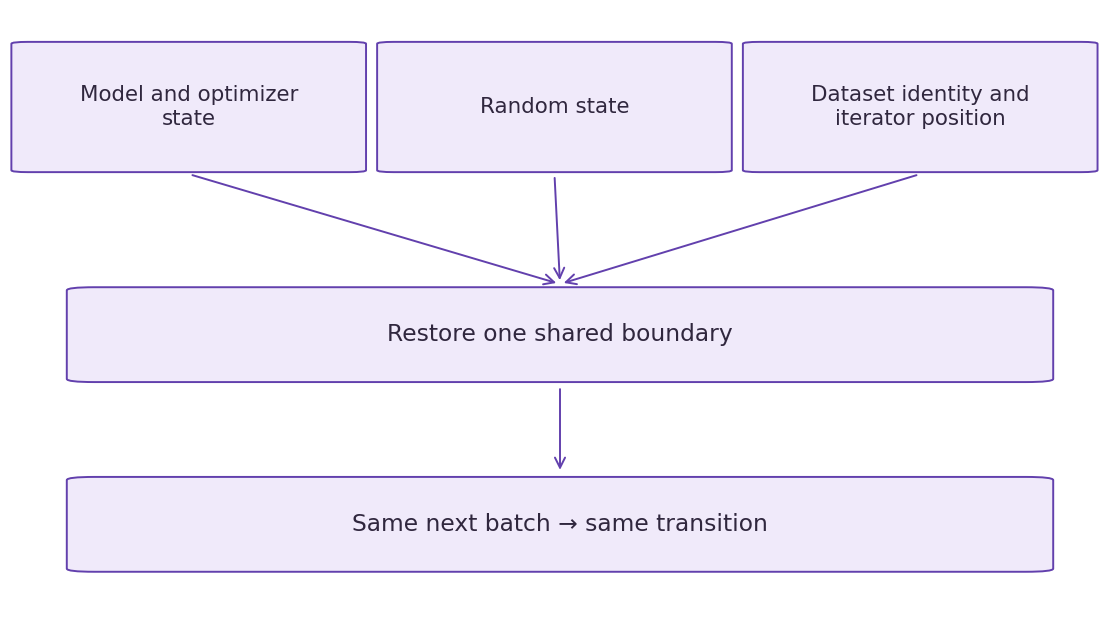

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The uninterrupted and resumed loss curves overlap to machine precision across steps 3 through 6.

### Connect it to the computation

Saving and restoring the step counter, PRNG key, data iterator state, and optimizer moments alongside model weights ensures exact continuation.

## Restart only the reader

Predict: Keep restored training state but start a fresh iterator. Which IDs arrive first, and should the next update match?

In [7]:
# Experiment — Restart only the reader: A model step counter does not automatically seek a data iterator.
fresh = iter(make_loader())
# Run `consume` to compute `(wrong_state, wrong_losses, wrong_ids)`.
wrong_state,wrong_losses,wrong_ids = consume(restored_payload["training"],fresh,1)
# Assert invariant `not np.array_equal(wrong_ids[0],reference_ids[0])` holds
assert not np.array_equal(wrong_ids[0],reference_ids[0])
# Assert that `not np.isclose(wrong_losses[0],reference_losses[0],rtol=1e-6,atol=1e-7)`.
assert not np.isclose(wrong_losses[0],reference_losses[0],rtol=1e-6,atol=1e-7)
# Print the observed values to compare against the expected result.
print("Missing iterator restore repeats earlier IDs and changes the next loss")

Expected: The first batch repeats instead of the saved next batch; the next loss differs.

A model step counter does not automatically seek a data iterator.

## Restore only the reader

Predict: Replay the correct IDs but initialize model/optimizer/key from scratch. Will losses match?

In [8]:
# Experiment — Restore only the reader: Input replay and model-state replay are complementary...
reader_only = iter(make_loader())
reader_only.set_state(unpack_bytes(restored_payload["pipeline"]))
# Run `consume` to compute `(wrong_model, wrong_model_losses, correct_ids)`.
wrong_model,wrong_model_losses,correct_ids = consume(initial_state(),reader_only,1)
# Execute `np.testing.assert_array_equal(correct_ids[0],reference_ids[0`
np.testing.assert_array_equal(correct_ids[0],reference_ids[0])
# Assert that `not np.isclose(wrong_model_losses[0],reference_losses[0],rtol=1e-6,atol=1e-7)`.
assert not np.isclose(wrong_model_losses[0],reference_losses[0],rtol=1e-6,atol=1e-7)
# Assert invariant `int(wrong_model["step"])==1` holds
assert int(wrong_model["step"])==1
# Print the observed values to compare against the expected result.
print("Correct IDs alone do not restore the training transition")

Expected: IDs agree but loss and step differ.

Input replay and model-state replay are complementary requirements; either alone can look superficially successful.

## Your exercise

Repeat the protocol after one batch and compare the next five batches through step six. Save to a distinct directory.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Run `consume` to compute `(other_state, _, _)`.
2. Compute `other_payload` from `{"training":other_state,"pipeline":pack_bytes(other_...`
3. Enter `ocp.StandardCheckpointer()` context block:
4. Read or serialize artifact data on disk (`other_path`).
5. Run `cp.save` to perform the next check or state transition.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Repeat the protocol after one batch and compare the next five batches...
other_iterator = iter(...)  # TODO: compute other_iterator
# Run `consume` to compute `(other_state, _, _)`.
other_state,_,_ = consume(...)  # TODO: compute other_state,_,_
# Compute `other_payload` from `{"training":other_state,"pipeline":pack_bytes(other_...`
other_payload = ...  # TODO: compute other_payload
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Read or serialize artifact data on disk (`other_path`).
    other_path = Path(...)  # TODO: compute other_path
    # Run `cp.save` to perform the next check or state transition.
    cp.save(other_path,other_payload)
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Run `cp.restore` to compute `other_saved`.
    other_saved = cp.restore(...)  # TODO: compute other_saved
# Run `iter` to compute `other_resumed`.
# Compute `other_resumed` as `iter(make_loader())`.
other_resumed = iter(...)  # TODO: compute other_resumed
other_resumed.set_state(unpack_bytes(other_saved["pipeline"]))
# Run `consume` to compute `(a, loss_a, ids_a)`.
a,loss_a,ids_a = consume(...)  # TODO: compute a,loss_a,ids_a
# Run `consume` to compute `(b, loss_b, ids_b)`.
b,loss_b,ids_b = consume(...)  # TODO: compute b,loss_b,ids_b
# Iterate over `(l, r)` to step through the computation:
for l,r in zip(ids_a,ids_b):np.testing.assert_array_equal(l,r)
# Compute `np.testing.assert_allclose(loss_a,loss_b,rtol` as `1e-6,atol=1e-7)`.
np.testing.assert_allclose(loss_a,loss_b,rtol = ...  # TODO: compute np.testing.assert_allclose(loss_a,loss_b,rtol
# Run `same_tree` to perform the next check or state transition.
same_tree(a,b)
# Assert invariant `int(b["step"])==6` holds
assert int(b["step"])  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Repeat the protocol after one batch and compare the next five batches...
# other_iterator = iter(...)  # TODO: compute other_iterator
# Run `consume` to compute `(other_state, _, _)`.
# other_state,_,_ = consume(...)  # TODO: compute other_state,_,_
# Compute `other_payload` from `{"training":other_state,"pipeline":pack_bytes(other_...`
# other_payload = ...  # TODO: compute other_payload
# Enter `ocp.StandardCheckpointer()` context block:
# with ocp.StandardCheckpointer() as cp:
    # Read or serialize artifact data on disk (`other_path`).
#     other_path = Path(...)  # TODO: compute other_path
    # Run `cp.save` to perform the next check or state transition.
#     cp.save(other_path,other_payload)
    # Run `cp.wait_until_finished` to perform the next check or state transition.
#     cp.wait_until_finished()
    # Run `cp.restore` to compute `other_saved`.
#     other_saved = cp.restore(...)  # TODO: compute other_saved
# Run `iter` to compute `other_resumed`.
# Compute `other_resumed` as `iter(make_loader())`.
# other_resumed = iter(...)  # TODO: compute other_resumed
# other_resumed.set_state(unpack_bytes(other_saved["pipeline"]))
# Run `consume` to compute `(a, loss_a, ids_a)`.
# a,loss_a,ids_a = consume(...)  # TODO: compute a,loss_a,ids_a
# Run `consume` to compute `(b, loss_b, ids_b)`.
# b,loss_b,ids_b = consume(...)  # TODO: compute b,loss_b,ids_b
# Iterate over `(l, r)` to step through the computation:
# for l,r in zip(ids_a,ids_b):np.testing.assert_array_equal(l,r)
# Compute `np.testing.assert_allclose(loss_a,loss_b,rtol` as `1e-6,atol=1e-7)`.
# np.testing.assert_allclose(loss_a,loss_b,rtol = ...  # TODO: compute np.testing.assert_allclose(loss_a,loss_b,rtol
# Run `same_tree` to perform the next check or state transition.
# same_tree(a,b)
# Assert invariant `int(b["step"])==6` holds
# assert int(b["step"])  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Repeat the protocol after one batch and compare the next five batches...
other_iterator = iter(make_loader())
# Run `consume` to compute `(other_state, _, _)`.
other_state,_,_ = consume(initial_state(),other_iterator,1)
# Compute `other_payload` from `{"training":other_state,"pipeline":pack_bytes(other_...`
other_payload = {"training":other_state,"pipeline":pack_bytes(other_iterator.get_state()),"contract":encode_contract(contract)}
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Read or serialize artifact data on disk (`other_path`).
    other_path = Path(tempfile.mkdtemp(dir=root))/"completed_step_1"
    # Run `cp.save` to perform the next check or state transition.
    cp.save(other_path,other_payload)
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Run `cp.restore` to compute `other_saved`.
    other_saved = cp.restore(other_path,target={"training":initial_state(),"pipeline":pack_bytes(b""),"contract":encode_contract(contract)})
# Run `iter` to compute `other_resumed`.
# Compute `other_resumed` as `iter(make_loader())`.
other_resumed = iter(make_loader())
other_resumed.set_state(unpack_bytes(other_saved["pipeline"]))
# Run `consume` to compute `(a, loss_a, ids_a)`.
a,loss_a,ids_a = consume(other_state,other_iterator,5)
# Run `consume` to compute `(b, loss_b, ids_b)`.
b,loss_b,ids_b = consume(other_saved["training"],other_resumed,5)
# Iterate over `(l, r)` to step through the computation:
for l,r in zip(ids_a,ids_b):np.testing.assert_array_equal(l,r)
# Compute `np.testing.assert_allclose(loss_a,loss_b,rtol` as `1e-6,atol=1e-7)`.
np.testing.assert_allclose(loss_a,loss_b,rtol=1e-6,atol=1e-7)
# Run `same_tree` to perform the next check or state transition.
same_tree(a,b)
# Assert invariant `int(b["step"])==6` holds
assert int(b["step"])==6

## Reject an incompatible resume before consuming data · Transfer

Try the saved contract with a changed sampler seed and then a changed dataset fingerprint. Both must fail before training resumes. Verify that the unchanged contract still passes.

Hint: Use validate_contract on copies of the expected contract; do not rewrite the saved payload.

### How to write: Reject an incompatible resume before consuming data — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `data(...)` — Call `data` with your updated parameters or inputs from this lesson's workspace.
- `validate_contract(...)` — Call `validate_contract` with your updated parameters or inputs from this lesson's workspace.

**Step-by-step implementation plan:**
1. Iterate over `(field, value)` to step through the computation:
2. Evaluate `contract, **{field: value}` and convert the result into Python scalar/collection `incompatible`.
3. Run the boundary check and catch the expected exception:
4. Run `validate_contract` to perform the next check or state transition.
5. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Reject an incompatible resume before consuming data (Transfer): Exact state replay only makes sense under a compatible data...
# Iterate over `(field, value)` to step through the computation:
for field,value in [('seed',43),('sha256','different-dataset')]:
    # Evaluate `contract, **{field: value}` and convert the result into Python scalar/collection `incompatible`.
    incompatible = dict(...)  # TODO: compute incompatible
    # Run the boundary check and catch the expected exception:
    try:validate_contract(restored_payload['contract'],incompatible)
    except ValueError:print('Rejected incompatible',field)
    else:raise AssertionError('Incompatible resume was accepted')
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored_payload['contract'],contract)
# Print the observed values to compare against the expected result.
print('Original run contract remains valid.')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Reject an incompatible resume before consuming data (Transfer): Exact state replay only makes sense under a compatible data...
# Iterate over `(field, value)` to step through the computation:
# for field,value in [('seed',43),('sha256','different-dataset')]:
    # Evaluate `contract, **{field: value}` and convert the result into Python scalar/collection `incompatible`.
#     incompatible = dict(...)  # TODO: compute incompatible
    # Run the boundary check and catch the expected exception:
#     try:validate_contract(restored_payload['contract'],incompatible)
#     except ValueError:print('Rejected incompatible',field)
#     else:raise AssertionError('Incompatible resume was accepted')
# Run `validate_contract` to perform the next check or state transition.
# validate_contract(restored_payload['contract'],contract)
# Print the observed values to compare against the expected result.
# print('Original run contract remains valid.')

## Reference reasoning

Exact state replay only makes sense under a compatible data and update contract. Rejecting a mismatch before consuming a batch keeps an invalid resume from looking like a successful run.

In [12]:
# Reject an incompatible resume before consuming data (Transfer): Exact state replay only makes sense under a compatible data...
# Iterate over `(field, value)` to step through the computation:
for field,value in [('seed',43),('sha256','different-dataset')]:
    # Evaluate `contract, **{field: value}` and convert the result into Python scalar/collection `incompatible`.
    incompatible=dict(contract,**{field:value})
    # Run the boundary check and catch the expected exception:
    try:validate_contract(restored_payload['contract'],incompatible)
    except ValueError:print('Rejected incompatible',field)
    else:raise AssertionError('Incompatible resume was accepted')
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored_payload['contract'],contract)
# Print the observed values to compare against the expected result.
print('Original run contract remains valid.')

## Reject changed batch size before consuming · Challenge

Pretend the resumed application now uses batch size three. Reject the saved contract before a reader is used, then restore the original configuration and check the next IDs.

Hint: The stored cursor is interpreted in a particular pipeline configuration.

### How to write: Reject changed batch size before consuming — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `consuming(...)` — Call `consuming` with your updated parameters or inputs from this lesson's workspace.
- `validate_contract(...)` — Call `validate_contract` with your updated parameters or inputs from this lesson's workspace.

**Step-by-step implementation plan:**
1. Run the boundary check and catch the expected exception:
2. Run `validate_contract` to perform the next check or state transition.
3. Run `iter` to compute `fixed_reader`.
4. Compute `fixed_reader` as `iter(make_loader())`.
5. Execute `np.testing.assert_array_equal(next(fixed_reader)["id"],refer`

**Starter code scaffold (fill in the TODOs):**

```python
# Reject changed batch size before consuming (Challenge): Changing batching changes consumption semantics.
changed = dict(...)  # TODO: compute changed
# Run the boundary check and catch the expected exception:
try:
    validate_contract(restored_payload["contract"],changed)
except ValueError:
    print("Expected batch-configuration mismatch")
else:
    raise AssertionError("Expected incompatible restore rejection")
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored_payload["contract"],contract)
# Run `iter` to compute `fixed_reader`.
# Compute `fixed_reader` as `iter(make_loader())`.
fixed_reader = iter(...)  # TODO: compute fixed_reader
fixed_reader.set_state(unpack_bytes(restored_payload["pipeline"]))
# Execute `np.testing.assert_array_equal(next(fixed_reader)["id"],refer`
np.testing.assert_array_equal(next(fixed_reader)["id"],reference_ids[0])
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Reject changed batch size before consuming (Challenge): Changing batching changes consumption semantics.
# changed = dict(...)  # TODO: compute changed
# Run the boundary check and catch the expected exception:
# try:
#     validate_contract(restored_payload["contract"],changed)
# except ValueError:
#     print("Expected batch-configuration mismatch")
# else:
#     raise AssertionError("Expected incompatible restore rejection")
# Run `validate_contract` to perform the next check or state transition.
# validate_contract(restored_payload["contract"],contract)
# Run `iter` to compute `fixed_reader`.
# Compute `fixed_reader` as `iter(make_loader())`.
# fixed_reader = iter(...)  # TODO: compute fixed_reader
# fixed_reader.set_state(unpack_bytes(restored_payload["pipeline"]))
# Execute `np.testing.assert_array_equal(next(fixed_reader)["id"],refer`
# np.testing.assert_array_equal(next(fixed_reader)["id"],reference_ids[0])

## Reference reasoning

Changing batching changes consumption semantics. Refuse the mismatched configuration instead of assuming that training step two corresponds to the same next examples.

In [14]:
# Reject changed batch size before consuming (Challenge): Changing batching changes consumption semantics.
changed = dict(contract,batch_size=3)
# Run the boundary check and catch the expected exception:
try:
    validate_contract(restored_payload["contract"],changed)
except ValueError:
    print("Expected batch-configuration mismatch")
else:
    raise AssertionError("Expected incompatible restore rejection")
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored_payload["contract"],contract)
# Run `iter` to compute `fixed_reader`.
# Compute `fixed_reader` as `iter(make_loader())`.
fixed_reader = iter(make_loader())
fixed_reader.set_state(unpack_bytes(restored_payload["pipeline"]))
# Execute `np.testing.assert_array_equal(next(fixed_reader)["id"],refer`
np.testing.assert_array_equal(next(fixed_reader)["id"],reference_ids[0])

## Checkpoint

Which evidence supports a consistent restart boundary?

1. The checkpoint directory exists.
2. The next IDs, losses and full training state match the uninterrupted future under a compatible contract.
3. The final loss eventually decreases.

## Diagnose

Changing batching changes consumption semantics. Refuse the mismatched configuration instead of assuming that training step two corresponds to the same next examples.

## Evidence

Keep the committed model/optimizer/key/iterator snapshot, uninterrupted and resumed batch-ID ledger across the epoch boundary, exact keys/counts, declared floating tolerances and inconsistent model-only/reader-only restart failures.

## Carry forward

- Commit one logical boundary
- Persist opaque iterator bytes without editing them
- Audit the future, including an epoch transition
- Define the limits of this recovery claim

## Primary references

- [NumPy Generator permutation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.permutation.html)
- [Grain DataLoader guide](https://google-grain.readthedocs.io/en/latest/tutorials/data_loader_tutorial.html)
- [Orbax StandardCheckpointer](https://orbax.readthedocs.io/en/latest/api_reference/checkpoint.checkpointers.html)
- [Optax Adam](https://optax.readthedocs.io/en/latest/api/optimizers.html#optax.adam)
- [JAX random key data](https://docs.jax.dev/en/latest/_autosummary/jax.random.key_data.html)